/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_27939/3761669585.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


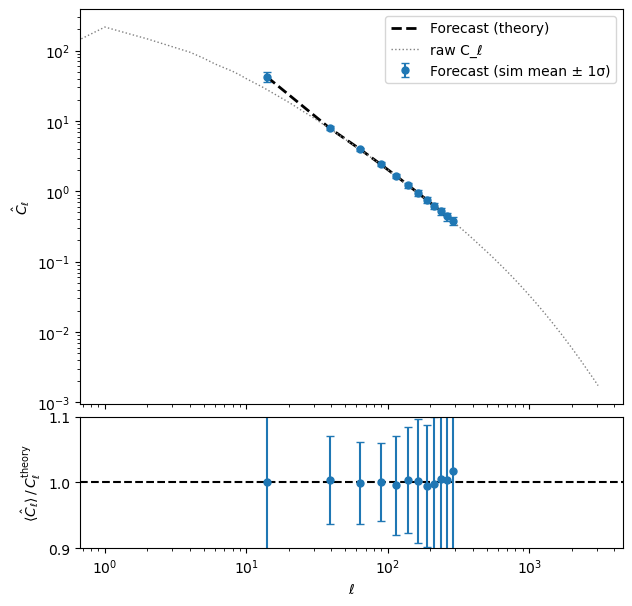

In [113]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

npz_files = {
    "Forecast": Path("../output/mock_masked_fixed.npz"),
}

dm_case = "pcl_dm"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

for label, path in npz_files.items():
    if not path.exists():
        print(f"Skipping {label}: {path} not found")
        continue

    d        = np.load(path, allow_pickle=False)
    ell_eff  = d["pcl_ell_eff"]
    mean_pcl = d[dm_case].mean(axis=0)
    cov      = np.cov(d[dm_case].T)
    err      = np.sqrt(np.diag(cov))
    theory   = d["pcl_theory"]

    # --- top panel ---
    ax_top.errorbar(
        ell_eff, mean_pcl, err,
        label=f"{label} (sim mean ± 1σ)",
        color="C0", lw=0, marker="o", markersize=5, elinewidth=1.5, capsize=3,
    )
    ax_top.plot(ell_eff, theory, color="k", lw=2, ls="--", label=f"{label} (theory)")
    ax_top.plot(d["ell"], d["cell"], color="grey", lw=1, ls=":", label="raw C_ℓ")

    ax_top.set_yscale("log")
    ax_top.set_xscale("log")
    ax_top.set_ylabel(r"$\hat{C}_\ell$")
    ax_top.legend()

    # --- bottom panel: ratio sim / theory ---
    ratio     = mean_pcl / theory
    ratio_err = err / theory

    ax_bot.axhline(1.0, color="k", lw=1.5, ls="--")
    ax_bot.errorbar(
        ell_eff, ratio, ratio_err,
        color="C0", lw=0, marker="o", markersize=5, elinewidth=1.5, capsize=3,
    )

ax_bot.set_xlabel(r"$\ell$")
ax_bot.set_ylabel(r"$\langle\hat{C}_\ell\rangle \,/\, C_\ell^{\rm theory}$")
ax_bot.set_ylim(0.9, 1.1)

plt.tight_layout()
plt.savefig("pcl_noiseless_ratio.png", dpi=150, bbox_inches="tight")
plt.show()


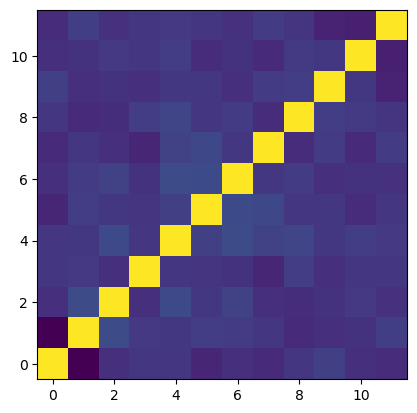

In [107]:
corr = np.corrcoef(d[dm_case].T)
plt.imshow(corr, origin="lower", cmap="viridis")

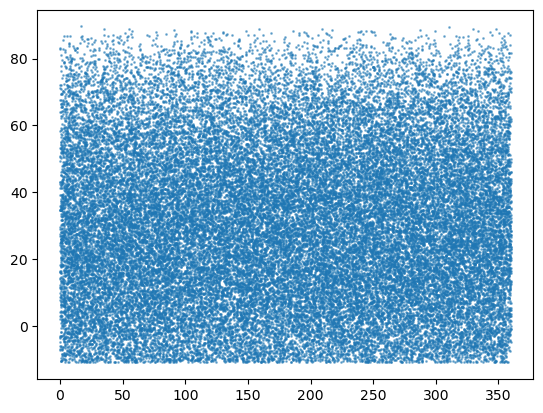

In [108]:
plt.scatter(d["ra"], d["dec"], s=1, alpha=0.5)